
# EDA: Narrow-Channel CHF (ML 2025) Source Summary (`narrowchannel_chf_ml2025_source_summary.csv`)

A small (4-row) summary table: one row per literature source used in a
narrow-channel CHF machine-learning study, giving the geometric/operating
**range** each source contributes (not raw data points). EDA here compares
coverage across sources rather than profiling a single distribution.

## 1. Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../../data/raw/external")
OUT_DIR = Path("../../results/eda/narrowchannel_chf_ml2025_source_summary")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_DIR / "narrowchannel_chf_ml2025_source_summary.csv")
df

,Source,Width_mm,Height_mm,Hydraulic_diameter_mm,Heated_length_mm,MassFlux_kg_m2s,InletSubcooling_K,Pressure_MPa,N_points
0,Du et al.,"20, 60","1.1, 2.5",2.09-4.44,150-690,30-4300,0-301,1-14,296
1,Huang et al.,60,0.5-3,0.99-5.71,750,50-200,10-60,1-8,312
2,Tang et al.,50,2,3.84,1000,300-1000,20-140,12-15,22
3,He et al.,70,2.7,5.20,700,135-711,20-70,0.14,30


## 2. Parse Ranges

In [2]:
import re

def parse_minmax(token):
    # Parse a range-ish string token into (min, max) floats.
    # Handles: '20, 60' (list), '2.09-4.44' (dash range),
    # '-0.5 to -0.25' (worded range, needed for negative bounds), '1000' (single value).
    if pd.isna(token):
        return np.nan, np.nan
    s = str(token).strip()
    if s == "":
        return np.nan, np.nan
    if " to " in s:
        a, b = s.split(" to ")
        a, b = float(a), float(b)
        return min(a, b), max(a, b)
    if "," in s:
        vals = [float(t.strip()) for t in s.split(",")]
        return min(vals), max(vals)
    m = re.match(r"^(-?\d+\.?\d*)-(-?\d+\.?\d*)$", s)
    if m:
        a, b = float(m.group(1)), float(m.group(2))
        return min(a, b), max(a, b)
    v = float(s)
    return v, v

In [3]:
range_cols = ["Width_mm", "Height_mm", "Hydraulic_diameter_mm", "Heated_length_mm",
              "MassFlux_kg_m2s", "InletSubcooling_K", "Pressure_MPa"]

parsed = df[["Source"]].copy()
for col in range_cols:
    mins, maxs = zip(*df[col].map(parse_minmax))
    parsed[f"{col}_min"] = mins
    parsed[f"{col}_max"] = maxs
parsed.to_csv(OUT_DIR / "parsed_ranges.csv", index=False)
parsed

,Source,Width_mm_min,Width_mm_max,Height_mm_min,Height_mm_max,Hydraulic_diameter_mm_min,Hydraulic_diameter_mm_max,Heated_length_mm_min,Heated_length_mm_max,MassFlux_kg_m2s_min,MassFlux_kg_m2s_max,InletSubcooling_K_min,InletSubcooling_K_max,Pressure_MPa_min,Pressure_MPa_max
0,Du et al.,20.0,60.0,1.1,2.5,2.09,4.44,150.0,690.0,30.0,4300.0,0.0,301.0,1.00,14.00
1,Huang et al.,60.0,60.0,0.5,3.0,0.99,5.71,750.0,750.0,50.0,200.0,10.0,60.0,1.00,8.00
2,Tang et al.,50.0,50.0,2.0,2.0,3.84,3.84,1000.0,1000.0,300.0,1000.0,20.0,140.0,12.00,15.00
3,He et al.,70.0,70.0,2.7,2.7,5.20,5.20,700.0,700.0,135.0,711.0,20.0,70.0,0.14,0.14


## 3. Range Coverage by Source

In [4]:
def plot_range_bars(ax, labels, mins, maxs, title, xlabel=""):
    y = np.arange(len(labels))
    ax.hlines(y, mins, maxs, color="#4C72B0", linewidth=6)
    ax.plot(mins, y, "|", color="#2f4b7c", markersize=14, markeredgewidth=2)
    ax.plot(maxs, y, "|", color="#2f4b7c", markersize=14, markeredgewidth=2)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()

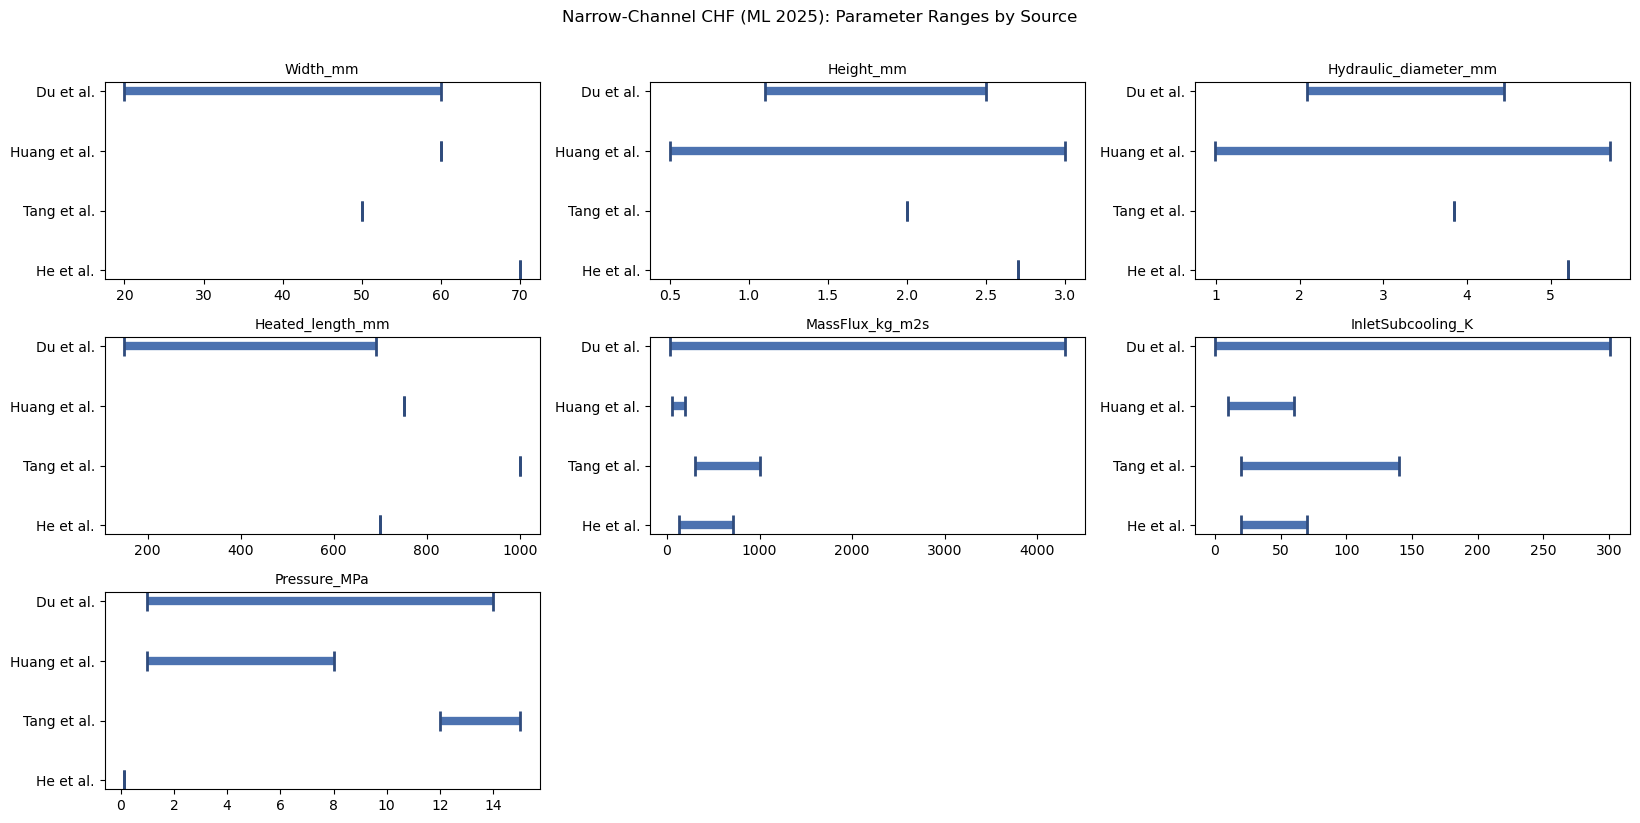

In [5]:
ncols = 3
nrows = -(-len(range_cols) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 0.9 * len(df) + 1.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, range_cols):
    plot_range_bars(ax, parsed["Source"], parsed[f"{col}_min"], parsed[f"{col}_max"], col)
for ax in axes[len(range_cols):]:
    ax.axis("off")
fig.suptitle("Narrow-Channel CHF (ML 2025): Parameter Ranges by Source", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "range_coverage_by_source.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Sample Counts by Source

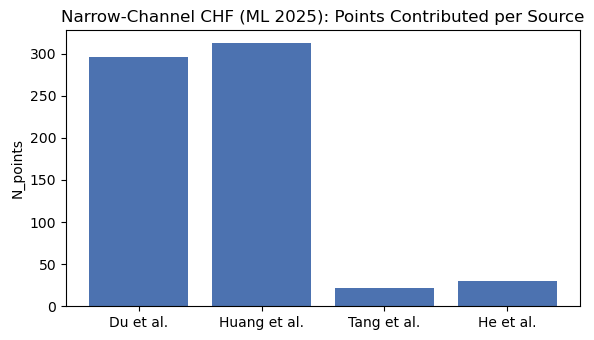

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(df["Source"], df["N_points"], color="#4C72B0")
ax.set_ylabel("N_points")
ax.set_title("Narrow-Channel CHF (ML 2025): Points Contributed per Source")
fig.tight_layout()
fig.savefig(FIG_DIR / "n_points_by_source.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Takeaways

- `Du et al.` contributes the widest hydraulic-diameter and mass-flux range;
  `He et al.` is a narrow, single-pressure (`0.14 MPa`) slice — check for
  gaps before pooling all four sources into one training set.
- Ranges given as multi-value lists (e.g. `Width_mm = "20, 60"`) mean only
  those discrete widths were tested, not a continuum — `parse_minmax` treats
  them as `[min, max]` bounds only, which can overstate actual coverage.
